In [ ]:
import tensorflow as tf
tf.keras.backend.set_floatx('float32')

import numpy as np
import matplotlib.pyplot as plt
from IPython import display

In [ ]:
def eos(P, K, gamma):
    if P <= 0:
        return 0.0, 0.0
    rho_b = (P / K) ** (1 / gamma)
    epsilon = rho_b + P / (gamma - 1)
    return rho_b, epsilon

def solve_tov_full(rho_c=1.28e-3, K=100, gamma=2, dr=0.05, r_max=15):
    P_c = K * rho_c ** gamma
    _, eps_c = eos(P_c, K, gamma)

    r_int, m_int, P_int = [0.0], [0.0], [P_c]

    r0 = 1e-6
    m0 = (4.0 / 3.0) * np.pi * eps_c * r0 ** 3
    P0 = P_c - (2.0 / 3.0) * np.pi * (eps_c + P_c) * (eps_c + 3.0 * P_c) * r0 ** 2

    r, m, P = r0, m0, P0
    r_int.append(r); m_int.append(m); P_int.append(P)

    while P > 1e-12 and r < r_max:
        rho_b, epsilon = eos(P, K, gamma)
        dm_dr = 4 * np.pi * r ** 2 * epsilon
        denom = r * (r - 2 * m)
        denom = denom if abs(denom) > 1e-10 else 1e-10
        dP_dr = -(epsilon + P) * (m + 4 * np.pi * r ** 3 * P) / denom

        m += dr * dm_dr
        P = max(P + dr * dP_dr, 0.0)
        r += dr
        r_int.append(r); m_int.append(m); P_int.append(P)

    return m_int[-1], r_int[-1], np.array(r_int), np.array(m_int), np.array(P_int)


def gen_tov_data(rho_c, K, gamma, dr=0.05, r_max=15):
    M, R, r, m, P = solve_tov_full(rho_c, K, gamma, dr, r_max)
    mask = r > 1e-6
    r, m, P = r[mask], m[mask], P[mask]
    return r, m, P, M, R

In [ ]:
def logit(x):
    return np.log(x / (1.0 - x))


class TOVModelInverse(tf.keras.models.Model):
    def __init__(self, base_model, K_init, rho_c_init, gamma_init):
        super(TOVModelInverse, self).__init__()

        self.model = base_model

        self.log_K = self.add_weight(shape=(), initializer=tf.keras.initializers.Constant(np.log(K_init)), dtype=tf.float32, trainable=True, name='log_K')

        self.log_rho_c = self.add_weight(shape=(), initializer=tf.keras.initializers.Constant(np.log(rho_c_init)), dtype=tf.float32, trainable=True, name='log_rho_c')

        gamma_min = 1.1
        gamma_max = 3.0
        y = (gamma_init - gamma_min) / (gamma_max - gamma_min)
        y = np.clip(y, 1e-6, 1.0 - 1e-6)

        self.gamma_raw = self.add_weight(shape=(), initializer=tf.keras.initializers.Constant(logit(y)), dtype=tf.float32, trainable=True, name='gamma_raw')

    def physics_params(self):
        K = tf.exp(self.log_K)
        rho_c = tf.exp(self.log_rho_c)

        gamma_min = tf.constant(1.1, dtype=tf.float32)
        gamma_max = tf.constant(3.0, dtype=tf.float32)
        gamma = gamma_min + (gamma_max - gamma_min) * tf.sigmoid(self.gamma_raw)

        return K, rho_c, gamma

    def call(self, r_n, **kwargs):
        return self.model(r_n)

In [ ]:
tovnet = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(1,), dtype=tf.float32),
    tf.keras.layers.Dense(128, activation='tanh', dtype=tf.float32),
    tf.keras.layers.Dense(128, activation='tanh', dtype=tf.float32),
    tf.keras.layers.Dense(128, activation='tanh', dtype=tf.float32),
    tf.keras.layers.Dense(128, activation='tanh', dtype=tf.float32),
    tf.keras.layers.Dense(2, dtype=tf.float32)
])

model = TOVModelInverse(tovnet, K_init=50.0, rho_c_init=4.8e-4, gamma_init=1.5)

_ = model(tf.constant([[0.0]], dtype=tf.float32))

In [ ]:
def constrained_outputs(model, r_n, norm):
    raw = model(r_n)
    raw_m = raw[:, 0:1]
    raw_P = raw[:, 1:2]

    m_scale = norm['m_scale']
    P_scale = norm['P_scale']
    Pc_obs = norm['Pc_obs']

    m_n = tf.pow(r_n, 3) * raw_m
    m_ph = m_n * m_scale

    P_ph = Pc_obs * (1.0 - r_n) * tf.exp(r_n * raw_P)
    P_n = P_ph / P_scale

    return m_n, P_n, m_ph, P_ph


@tf.function(jit_compile=False)
def tov_inv_loss(model, r_n, m_n_train, P_n_train, norm, lam_data, lam_tov, lam_pc):

    pi = tf.constant(np.pi, dtype=tf.float32)
    eps = tf.constant(1e-12, dtype=tf.float32)

    r_scale = norm['r_scale']
    m_scale = norm['m_scale']
    P_scale = norm['P_scale']
    Pc_obs = norm['Pc_obs']

    K, rho_c, gamma = model.physics_params()
    P_c = K * tf.pow(rho_c, gamma)

    pc_loss = tf.reduce_mean(tf.square((P_c - Pc_obs) / Pc_obs))

    m_n_pred, P_n_pred, _, _ = constrained_outputs(model, r_n, norm)

    data_loss = (tf.reduce_mean(tf.square(m_n_pred - m_n_train)) + tf.reduce_mean(tf.square(P_n_pred - P_n_train)))

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(r_n)
        m_n, P_n, m_ph, P_ph = constrained_outputs(model, r_n, norm)

    dm_n_dr_n = tape.gradient(m_n, r_n)
    dP_n_dr_n = tape.gradient(P_n, r_n)
    del tape

    r_ph = r_n * r_scale

    dm_dr = dm_n_dr_n * m_scale / r_scale
    dP_dr = dP_n_dr_n * P_scale / r_scale

    P_safe = tf.maximum(P_ph, eps)

    rho_b = tf.pow(P_safe / K, 1.0 / gamma)
    epsilon = rho_b + P_safe / (gamma - 1.0)

    denom = r_ph * (r_ph - 2.0 * m_ph)
    denom = tf.where(tf.abs(denom) < tf.constant(1e-10, dtype=tf.float32), tf.constant(1e-10, dtype=tf.float32) * tf.ones_like(denom), denom)

    res_m = dm_dr - 4.0 * pi * r_ph**2 * epsilon

    res_P = dP_dr + (epsilon + P_safe) * (m_ph + 4.0 * pi * r_ph**3 * P_safe) / denom

    tov_loss = (tf.reduce_mean(tf.square(res_m / (m_scale / r_scale))) + tf.reduce_mean(tf.square(res_P / (P_scale / r_scale))))

    total_loss = (lam_data * data_loss + lam_tov * tov_loss + lam_pc * pc_loss)

    return total_loss, data_loss, tov_loss, pc_loss

In [ ]:
# class BFGSTOVEnhanced:
#     """
#     BFGS wrapper with additional EOS constraint at center.
#     """
#     def __init__(self, model, lam_data=10.0, lam_tov=1.0, lam_pc=10.0, lam_eos=100.0):
#         self.model = model
#         self.lam_data = lam_data
#         self.lam_tov = lam_tov
#         self.lam_pc = lam_pc
#         self.lam_eos = lam_eos  # NEW: EOS constraint weight
        
#         shapes = [tf.shape(v) for v in model.trainable_variables]
#         n_tensors = len(shapes)
#         count = 0
#         idx = [] 
#         part = [] 

#         for i, shape in enumerate(shapes):
#             n = np.prod(shape)
#             idx.append(tf.reshape(tf.range(count, count+n, dtype=tf.int32), shape))
#             part.extend([i]*n)
#             count += n

#         self.part = tf.constant(part)
#         self.shapes = shapes
#         self.n_tensors = n_tensors
#         self.idx = idx

#     @tf.function
#     def assign_new_model_parameters(self, params_1d):
#         params = tf.dynamic_partition(params_1d, self.part, self.n_tensors)
#         for i, (shape, param) in enumerate(zip(self.shapes, params)):
#             self.model.trainable_variables[i].assign(tf.reshape(param, shape))

#     @tf.function
#     def loss_and_grads(self, params_1d):
#         self.assign_new_model_parameters(params_1d)

#         with tf.GradientTape() as tape:
#             loss, data_l, tov_l, pc_l = tov_inv_loss(self.model, R_train, M_train, P_train_n, norm_consts, self.lam_data, self.lam_tov, self.lam_pc)
            
#             #EOS constraint at center
#             K, rho_c, gamma = self.model.physics_params()
#             P_c = K * tf.pow(rho_c, gamma)
#             Pc_obs = norm_consts['Pc_obs']
            
#             #EOS constraint: rho_b,c should equal rho_c
#             rho_b_c = tf.pow(Pc_obs / K, 1.0 / gamma)
#             eos_loss = tf.square((rho_b_c - rho_c) / rho_c)
            
#             total_loss = loss + self.lam_eos * eos_loss

#         grads = tape.gradient(total_loss, self.model.trainable_variables)
#         grads = tf.dynamic_stitch(self.idx, grads)

#         return total_loss, grads

#     def __call__(self, params_1d):
#         loss, grads = self.loss_and_grads(tf.constant(params_1d, dtype=tf.float32))
#         return loss.numpy(), grads.numpy()

class BFGSTOVEnhanced:
    """
    BFGS wrapper with additional EOS constraint at center.
    Now takes r_n, m_n_train, P_n_train, norm as explicit inputs
    instead of relying on global variables.
    """
    def __init__(self, model, r_n, m_n_train, P_n_train, norm,
                 lam_data=10.0, lam_tov=1.0, lam_pc=10.0, lam_eos=100.0):
        self.model = model

        # store data/norm as attributes (fixes the global-variable leak)
        self.r_n = r_n
        self.m_n_train = m_n_train
        self.P_n_train = P_n_train
        self.norm = norm

        self.lam_data = lam_data
        self.lam_tov = lam_tov
        self.lam_pc = lam_pc
        self.lam_eos = lam_eos

        shapes = [tf.shape(v) for v in model.trainable_variables]
        n_tensors = len(shapes)
        count = 0
        idx = []
        part = []

        for i, shape in enumerate(shapes):
            n = np.prod(shape)
            idx.append(tf.reshape(tf.range(count, count+n, dtype=tf.int32), shape))
            part.extend([i]*n)
            count += n

        self.part = tf.constant(part)
        self.shapes = shapes
        self.n_tensors = n_tensors
        self.idx = idx

    @tf.function
    def assign_new_model_parameters(self, params_1d):
        params = tf.dynamic_partition(params_1d, self.part, self.n_tensors)
        for i, (shape, param) in enumerate(zip(self.shapes, params)):
            self.model.trainable_variables[i].assign(tf.reshape(param, shape))

    @tf.function
    def loss_and_grads(self, params_1d):
        self.assign_new_model_parameters(params_1d)

        with tf.GradientTape() as tape:
            loss, data_l, tov_l, pc_l = tov_inv_loss(
                self.model, self.r_n, self.m_n_train, self.P_n_train, self.norm,
                self.lam_data, self.lam_tov, self.lam_pc)

            # EOS constraint at center
            K, rho_c, gamma = self.model.physics_params()
            P_c = K * tf.pow(rho_c, gamma)
            Pc_obs = self.norm['Pc_obs']       # <-- use self.norm, not norm_consts

            rho_b_c = tf.pow(Pc_obs / K, 1.0 / gamma)
            eos_loss = tf.square((rho_b_c - rho_c) / rho_c)

            total_loss = loss + self.lam_eos * eos_loss

        grads = tape.gradient(total_loss, self.model.trainable_variables)
        grads = tf.dynamic_stitch(self.idx, grads)

        return total_loss, grads

    def __call__(self, params_1d):
        loss, grads = self.loss_and_grads(tf.constant(params_1d, dtype=tf.float32))
        return loss.numpy(), grads.numpy()

In [ ]:
history = []
history_data = []
history_tov = []
history_pc = []

r_train, m_train, P_train, M_true, R_true = gen_tov_data(rho_c=1.28e-3, K=100, gamma=2, dr=0.05, r_max=15)

r_scale = r_train.max()
m_scale = m_train.max()
P_scale = P_train.max()

norm_consts = {
    'r_scale': tf.constant(r_scale, dtype=tf.float32),
    'm_scale': tf.constant(m_scale, dtype=tf.float32),
    'P_scale': tf.constant(P_scale, dtype=tf.float32),
    'Pc_obs':  tf.constant(P_train[0], dtype=tf.float32)
}

R_train = tf.convert_to_tensor((r_train / r_scale).reshape(-1, 1), dtype=tf.float32)
M_train = tf.convert_to_tensor((m_train / m_scale).reshape(-1, 1), dtype=tf.float32)
P_train_n = tf.convert_to_tensor((P_train / P_scale).reshape(-1, 1), dtype=tf.float32)

r_test = np.linspace(0.0, r_train.max(), 300)
R_test = tf.convert_to_tensor((r_test / r_scale).reshape(-1, 1), dtype=tf.float32)

In [ ]:
lr_nn = tf.keras.optimizers.schedules.ExponentialDecay(2e-3, decay_steps=1000, decay_rate=0.9, staircase=False)

lr_phys = tf.keras.optimizers.schedules.ExponentialDecay(5e-5, decay_steps=1000, decay_rate=0.9, staircase=False)

optimiser_nn = tf.keras.optimizers.Adam(learning_rate=lr_nn)
optimiser_phys = tf.keras.optimizers.Adam(learning_rate=lr_phys)


@tf.function(jit_compile=False)
def inv_train_one_step_tov(model, r_n, m_n_train, P_n_train, norm, lam_data, lam_tov, lam_pc, opt_nn, opt_phys):

    nn_vars = model.model.trainable_variables
    phys_vars = [model.log_K, model.log_rho_c, model.gamma_raw]

    with tf.GradientTape() as tape:
        loss_value, data_l, tov_l, pc_l = tov_inv_loss(model, r_n, m_n_train, P_n_train, norm, lam_data, lam_tov, lam_pc)

    grads = tape.gradient(loss_value, nn_vars + phys_vars)

    grads_nn = grads[:len(nn_vars)]
    grads_phys = grads[len(nn_vars):]

    grads_nn = [tf.clip_by_norm(g, 10.0) if g is not None else None for g in grads_nn]

    grads_phys = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in grads_phys]

    nn_pairs = [(g, v) for g, v in zip(grads_nn, nn_vars) if g is not None]
    phys_pairs = [(g, v) for g, v in zip(grads_phys, phys_vars) if g is not None]

    if len(nn_pairs) > 0:
        opt_nn.apply_gradients(nn_pairs)

    if len(phys_pairs) > 0:
        opt_phys.apply_gradients(phys_pairs)

    return loss_value, data_l, tov_l, pc_l


history = []
history_data = []
history_tov = []
history_pc = []

num_epochs = 10000
pretrain_epochs = 1000
ramp_epochs = 3000
lam_tov_max = 1e-3

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 3.5))

for epoch in range(num_epochs):

    if epoch < pretrain_epochs:
        ramp = 0.0
    else:
        ramp = min(1.0, (epoch - pretrain_epochs) / ramp_epochs)

    lam_data = tf.constant(100.0, dtype=tf.float32)
    lam_tov = tf.constant(lam_tov_max * ramp, dtype=tf.float32)
    lam_pc = tf.constant(1.0 * ramp, dtype=tf.float32)

    loss, data_l, tov_l, pc_l = inv_train_one_step_tov(model, R_train, M_train, P_train_n, norm_consts, lam_data, lam_tov, lam_pc, optimiser_nn, optimiser_phys)

    history.append(loss.numpy())
    history_data.append(data_l.numpy())
    history_tov.append(tov_l.numpy())
    history_pc.append(pc_l.numpy())

    if epoch % 100 == 0:
        K_val, rho_c_val, gamma_val = model.physics_params()
        K_val = K_val.numpy()
        rho_c_val = rho_c_val.numpy()
        gamma_val = gamma_val.numpy()

        m_n_test, P_n_test, m_ph_test, P_ph_test = constrained_outputs(model, R_test, norm_consts)

        m_int = m_ph_test.numpy()
        P_int = P_ph_test.numpy()

        ax1.cla()
        ax1.set_yscale('log')
        ax1.set_xlabel('epoch')
        ax1.set_ylabel('loss')
        ax1.plot(history, label='total')
        ax1.plot(history_data, label='data', alpha=0.7)
        ax1.plot(history_tov, label='TOV', alpha=0.7)
        ax1.plot(history_pc, label='Pc', alpha=0.7)
        ax1.legend(fontsize=7)
        ax1.set_title(f'$K={K_val:.3f}$ ({abs(K_val-100)/100*100:.1f}%)', fontsize=10)

        ax2.cla()
        ax2.set_xlabel('r')
        ax2.set_ylabel('m(r)')
        ax2.plot(r_test, m_int, label='m(r) NN')
        ax2.scatter(r_train, m_train, s=10, color='orange', label='m data')
        ax2.legend(fontsize=8)
        ax2.set_title(f'$\\rho_c={rho_c_val:.3e}$ ({abs(rho_c_val-1.28e-3)/1.28e-3*100:.1f}%)', fontsize=10)

        ax3.cla()
        ax3.set_xlabel('r')
        ax3.set_ylabel('P(r)')
        ax3.plot(r_test, P_int, label='P(r) NN', color='green')
        ax3.scatter(r_train, P_train, s=10, color='red', label='P data')
        ax3.legend(fontsize=8)
        ax3.set_title(f'$\\gamma={gamma_val:.4f}$ ({abs(gamma_val-2.0)/2.0*100:.1f}%)', fontsize=10)

        display.display(plt.gcf())
        display.clear_output(wait=True)
        plt.tight_layout()

In [ ]:
print("Starting enhanced BFGS refinement...")
bfgs_func = BFGSTOVEnhanced(
    model,
    R_train, M_train, P_train_n, norm_consts,   # <-- explicit data + norm
    lam_data=10.0, lam_tov=1.0, lam_pc=50.0, lam_eos=200.0
)

#Get initial parameters
initial_params = tf.concat([tf.reshape(v, [-1]) for v in model.trainable_variables], axis=0)

from scipy.optimize import minimize

result = minimize(fun=lambda x: bfgs_func(x)[0], x0=initial_params.numpy(), jac=lambda x: bfgs_func(x)[1], method='L-BFGS-B', options={'maxiter': 15000, 'disp': True})

print(f"BFGS finished. Final loss: {result.fun}")

#Update model with BFGS result
bfgs_func.assign_new_model_parameters(tf.constant(result.x, dtype=tf.float32))

K_val, rho_c_val, gamma_val = model.physics_params()
K_val = K_val.numpy()
rho_c_val = rho_c_val.numpy()
gamma_val = gamma_val.numpy()

m_n_test, P_n_test, m_ph_test, P_ph_test = constrained_outputs(model, R_test, norm_consts)

m_int = m_ph_test.numpy()
P_int = P_ph_test.numpy()

fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(12, 4))

ax2.set_xlabel('r')
ax2.set_ylabel('m(r)')
ax2.plot(r_test, m_int, label='m(r) NN')
ax2.scatter(r_train, m_train, s=10, color='orange', label='m data')
ax2.legend(fontsize=8)

ax3.set_xlabel('r')
ax3.set_ylabel('P(r)')
ax3.plot(r_test, P_int, label='P(r) NN', color='green')
ax3.scatter(r_train, P_train, s=10, color='red', label='P data')
ax3.legend(fontsize=8)

plt.suptitle(
    f'After Enhanced BFGS: K={K_val:.3f} ({abs(K_val-100)/100*100:.1f}%), '
    f'ρ_c={rho_c_val:.3e} ({abs(rho_c_val-1.28e-3)/1.28e-3*100:.1f}%), '
    f'γ={gamma_val:.4f} ({abs(gamma_val-2.0)/2.0*100:.1f}%)',
    fontsize=12
)
plt.tight_layout()
plt.show()

epoch 0: loss=3.1383e+01  K=80.000 rho_c=1.2000e-03 gamma=1.6000
epoch 1000: loss=3.9125e-03  K=80.000 rho_c=1.2000e-03 gamma=1.6000
epoch 2000: loss=2.1671e+00  K=73.609 rho_c=1.1077e-03 gamma=1.6292
epoch 3000: loss=2.2353e+00  K=70.550 rho_c=1.0619e-03 gamma=1.6455
epoch 4000: loss=1.7954e+00  K=68.076 rho_c=1.0247e-03 gamma=1.6595
epoch 5000: loss=9.4830e-01  K=65.966 rho_c=9.9292e-04 gamma=1.6720
epoch 6000: loss=4.7981e-01  K=64.136 rho_c=9.6538e-04 gamma=1.6833
epoch 7000: loss=2.2339e-01  K=62.537 rho_c=9.4130e-04 gamma=1.6935
epoch 8000: loss=8.9514e-02  K=61.188 rho_c=9.2017e-04 gamma=1.7028
epoch 9000: loss=3.1337e-02  K=60.355 rho_c=9.0300e-04 gamma=1.7113


C:\Users\harsh\AppData\Local\Temp\ipykernel_25364\46576496.py:87: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(fun=lambda x: bfgs(x)[0], x0=x0, jac=lambda x: bfgs(x)[1],


K error:      26.817846 %
rho_c error:  0.5602487 %
gamma error:  2.5902193 %
m(r) Error:  0.19%
P(r) Error:  0.74%
Mass Error:  0.08%
Radius Error:0.00%


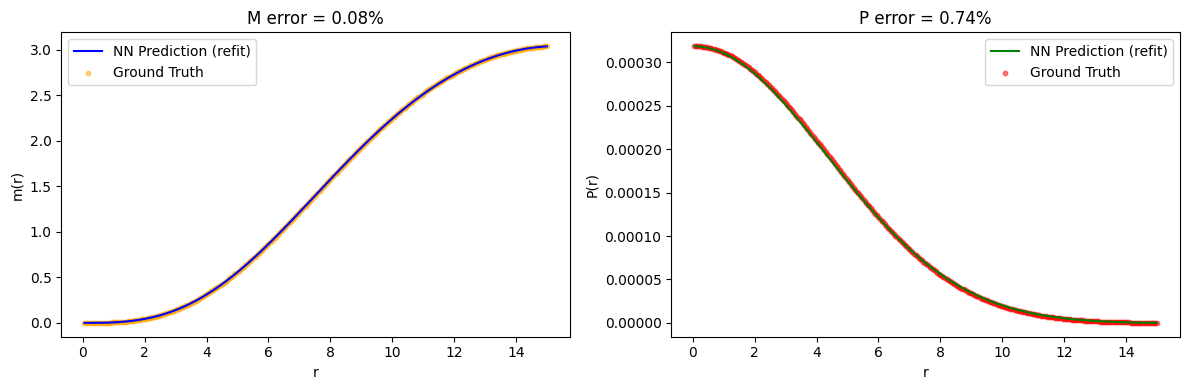

In [14]:
def fit_tov_inverse(r_data, m_data, P_data,
                     K_init, rho_c_init, gamma_init,
                     num_epochs=10000, pretrain_epochs=1000, ramp_epochs=3000,
                     lam_tov_max=1e-3, verbose=False):

    r_scale = r_data.max()
    m_scale = m_data.max()
    P_scale = P_data.max()

    norm = {
        'r_scale': tf.constant(r_scale, dtype=tf.float32),
        'm_scale': tf.constant(m_scale, dtype=tf.float32),
        'P_scale': tf.constant(P_scale, dtype=tf.float32),
        'Pc_obs':  tf.constant(P_data[0], dtype=tf.float32),
    }

    R_ = tf.convert_to_tensor((r_data / r_scale).reshape(-1,1), dtype=tf.float32)
    M_ = tf.convert_to_tensor((m_data / m_scale).reshape(-1,1), dtype=tf.float32)
    P_ = tf.convert_to_tensor((P_data / P_scale).reshape(-1,1), dtype=tf.float32)

    net = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(1,), dtype=tf.float32),
        tf.keras.layers.Dense(128, activation='tanh'),
        tf.keras.layers.Dense(128, activation='tanh'),
        tf.keras.layers.Dense(128, activation='tanh'),
        tf.keras.layers.Dense(128, activation='tanh'),
        tf.keras.layers.Dense(2)
    ])
    m = TOVModelInverse(net, K_init=K_init, rho_c_init=rho_c_init, gamma_init=gamma_init)
    _ = m(tf.constant([[0.0]], dtype=tf.float32))

    opt_nn = tf.keras.optimizers.Adam(
        tf.keras.optimizers.schedules.ExponentialDecay(2e-3, 1000, 0.9))
    opt_phys = tf.keras.optimizers.Adam(
        tf.keras.optimizers.schedules.ExponentialDecay(5e-5, 1000, 0.9))

    # --- Fresh, locally-scoped train step: closes over m, opt_nn, opt_phys ---
    @tf.function(jit_compile=False)
    def train_step(r_n, m_n_train, P_n_train, norm, lam_data, lam_tov, lam_pc):
        nn_vars = m.model.trainable_variables
        phys_vars = [m.log_K, m.log_rho_c, m.gamma_raw]

        with tf.GradientTape() as tape:
            loss_value, data_l, tov_l, pc_l = tov_inv_loss(
                m, r_n, m_n_train, P_n_train, norm, lam_data, lam_tov, lam_pc)

        grads = tape.gradient(loss_value, nn_vars + phys_vars)

        grads_nn = grads[:len(nn_vars)]
        grads_phys = grads[len(nn_vars):]

        grads_nn = [tf.clip_by_norm(g, 10.0) if g is not None else None for g in grads_nn]
        grads_phys = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in grads_phys]

        nn_pairs = [(g, v) for g, v in zip(grads_nn, nn_vars) if g is not None]
        phys_pairs = [(g, v) for g, v in zip(grads_phys, phys_vars) if g is not None]

        if len(nn_pairs) > 0:
            opt_nn.apply_gradients(nn_pairs)
        if len(phys_pairs) > 0:
            opt_phys.apply_gradients(phys_pairs)

        return loss_value, data_l, tov_l, pc_l
    # ---------------------------------------------------------------------

    loss_hist = []
    for epoch in range(num_epochs):
        ramp = 0.0 if epoch < pretrain_epochs else min(1.0, (epoch-pretrain_epochs)/ramp_epochs)
        lam_data = tf.constant(100.0, dtype=tf.float32)
        lam_tov  = tf.constant(lam_tov_max*ramp, dtype=tf.float32)
        lam_pc   = tf.constant(1.0*ramp, dtype=tf.float32)

        loss, data_l, tov_l, pc_l = train_step(R_, M_, P_, norm, lam_data, lam_tov, lam_pc)
        loss_hist.append(loss.numpy())

        if verbose and epoch % 1000 == 0:
            K_v, rho_v, g_v = m.physics_params()
            print(f"epoch {epoch}: loss={loss.numpy():.4e}  "
                  f"K={K_v.numpy():.3f} rho_c={rho_v.numpy():.4e} gamma={g_v.numpy():.4f}")

    # BFGS refine
    bfgs = BFGSTOVEnhanced(m, R_, M_, P_, norm,
                            lam_data=10.0, lam_tov=1.0, lam_pc=50.0, lam_eos=200.0)

    x0 = tf.concat([tf.reshape(v,[-1]) for v in m.trainable_variables], axis=0).numpy()
    from scipy.optimize import minimize
    res = minimize(fun=lambda x: bfgs(x)[0], x0=x0, jac=lambda x: bfgs(x)[1],
                    method='L-BFGS-B', options={'maxiter':15000, 'disp': verbose})
    bfgs.assign_new_model_parameters(tf.constant(res.x, dtype=tf.float32))

    K_f, rho_c_f, gamma_f = m.physics_params()
    return m, norm, (K_f.numpy(), rho_c_f.numpy(), gamma_f.numpy()), loss_hist

new_K = 80.0
new_rho_c = 1.0e-3
new_gamma = 1.8

r_new, m_new, P_new, M_true, R_true = gen_tov_data(
    rho_c=new_rho_c, K=new_K, gamma=new_gamma, dr=0.05, r_max=15
)

model_new, norm_new, (K_rec, rho_c_rec, gamma_rec), loss_hist_new = fit_tov_inverse(
    r_new, m_new, P_new,
    K_init=80.0, rho_c_init=1.2e-3, gamma_init=1.6,
    num_epochs=10000, pretrain_epochs=1000, ramp_epochs=3000,
    verbose=True
)

print("K error:     ", abs(K_rec-new_K)/new_K*100, "%")
print("rho_c error: ", abs(rho_c_rec-new_rho_c)/new_rho_c*100, "%")
print("gamma error: ", abs(gamma_rec-new_gamma)/new_gamma*100, "%")

R_new_n = tf.convert_to_tensor((r_new / norm_new['r_scale'].numpy()).reshape(-1,1), dtype=tf.float32)

m_n_pred, P_n_pred, m_ph_pred, P_ph_pred = constrained_outputs(model_new, R_new_n, norm_new)

m_pred = m_ph_pred.numpy().flatten()
P_pred = P_ph_pred.numpy().flatten()

m_error = np.mean(np.abs(m_pred - m_new)) / np.mean(m_new) * 100
P_error = np.mean(np.abs(P_pred - P_new)) / np.mean(P_new) * 100

M_pred = m_pred[-1]
below_thresh = np.where(P_pred < 1e-8)[0]
R_pred = r_new[below_thresh[0]] if len(below_thresh) > 0 else r_new[-1]

M_error = abs(M_pred - M_true) / M_true * 100
R_error = abs(R_pred - R_true) / R_true * 100

print(f"m(r) Error:  {m_error:.2f}%")
print(f"P(r) Error:  {P_error:.2f}%")
print(f"Mass Error:  {M_error:.2f}%")
print(f"Radius Error:{R_error:.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(r_new, m_pred, 'b-', label='NN Prediction (refit)')
ax1.scatter(r_new, m_new, s=10, color='orange', label='Ground Truth', alpha=0.5)
ax1.set_xlabel('r'); ax1.set_ylabel('m(r)'); ax1.legend()
ax1.set_title(f'M error = {M_error:.2f}%')

ax2.plot(r_new, P_pred, 'g-', label='NN Prediction (refit)')
ax2.scatter(r_new, P_new, s=10, color='red', label='Ground Truth', alpha=0.5)
ax2.set_xlabel('r'); ax2.set_ylabel('P(r)'); ax2.legend()
ax2.set_title(f'P error = {P_error:.2f}%')
plt.tight_layout()
plt.show()